# Essentia DEAM MusiCNN — Valence Key Correction Benchmark

Evaluates the **deam-musicnn** Essentia head with the key-mode valence correction applied.
This combines the strongest cross-dataset Essentia backbone (`deam-msd-musicnn-2.pb`)
with the valence calibration from `feat/valence_key_correction`.

**Correction formula:** `valence += α × (is_major − 0.5) × key_strength`  
where `α = 0.13` (calibrated on EmoMusic: mean valence major ≈ 5.8/9 vs minor ≈ 4.6/9)
and `key_strength` is the HPCP-based KeyExtractor confidence ∈ [0, 1].

| Model | Backbone | Head | Correction |
|-------|----------|------|------------|
| **This notebook** | MusiCNN | DEAM | Key-mode valence |
| `01_essentia_benchmark` | MusiCNN | EmoMusic | None |
| `01c_essentia_valence_key_correction` | MusiCNN | EmoMusic | Key-mode valence |

> **NOTE:** essentia-tensorflow is CPU-only — selecting a GPU runtime does not help here.

### Sections
0. Environment setup
1. Shared evaluation utilities
2. Essentia model files
3. Predictor (DEAM head + key-mode valence correction)
4. Datasets
5. Evaluation
6. Qualitative spot-checks
7. Profiling
8. Summary

## 0. Environment Setup

In [1]:
!pip install essentia-tensorflow yt-dlp librosa matplotlib pandas scipy tqdm gdown -q
print("Setup complete.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.8/183.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.5/291.5 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 80.9 MB/s eta 0:00:00
Setup complete.


## 1. Shared Evaluation Utilities

In [2]:
import os, sys
from pathlib import Path

REPO_BRANCH = "feat/mood-model-benchmark"
REPO_NAME   = "Soundtrack-Mood-Manager"

_cwd = Path.cwd()
if (_cwd / "eval_datasets.py").exists():
    _eval_dir = _cwd
else:
    _repo_root = _cwd / REPO_NAME
    if not (_repo_root / "evaluation").exists():
        !git clone --depth 1 --branch {REPO_BRANCH} \
            https://github.com/francescovidaich964/{REPO_NAME}.git
    _eval_dir = _repo_root / "evaluation"

_eval_dir = _eval_dir.resolve()
if str(_eval_dir) not in sys.path:
    sys.path.insert(0, str(_eval_dir))

from eval_datasets import (setup_deam, setup_emomusic, setup_pmemo, setup_merge,
                            detect_audio_paths, download_model_files)
from metrics import compute_metrics, print_metrics, print_summary
from visualization import plot_scatter, cross_dataset_comparison, plot_spot_checks
from spot_checks import (SPOT_CHECKS, download_spot_checks, run_evaluation,
                         profile_predictor, run_spot_checks, save_results)

import math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR      = Path("data")
MODELS_DIR    = Path("models")
SPOTCHECK_DIR = Path("spotchecks")
for d in [DATA_DIR, MODELS_DIR, SPOTCHECK_DIR]:
    d.mkdir(exist_ok=True)

MODEL_TAG = "deam-musicnn-valence-corrected"
print(f"Imports complete. (eval_dir={_eval_dir})")

Cloning into 'Soundtrack-Mood-Manager'...
remote: Enumerating objects: 52, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 52 (delta 1), reused 27 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (52/52), 1.88 MiB | 8.70 MiB/s, done.
Resolving deltas: 100% (1/1), done.
Imports complete. (eval_dir=/kaggle/working/Soundtrack-Mood-Manager/evaluation)


## 2. Download Essentia Model Files

MusiCNN feature extractor (shared with production) + DEAM regression head.

In [3]:
MODEL_URLS = {
    "msd-musicnn-1.pb":
        "https://essentia.upf.edu/models/feature-extractors/musicnn/msd-musicnn-1.pb",
    "deam-msd-musicnn-2.pb":
        "https://essentia.upf.edu/models/classification-heads/deam/deam-msd-musicnn-2.pb",
}

download_model_files(MODEL_URLS, MODELS_DIR)

## 3. Predictor

In [4]:
# Valence correction alpha: calibrated on EmoMusic (major vs minor gap ≈ 0.13)
_ALPHA = 0.13


class EssentiaPredictor:
    """DEAM MusiCNN head with key-mode valence correction.

    Uses deam-msd-musicnn-2.pb as the regression head instead of the production
    emomusic head. The DEAM head showed the best cross-dataset valence and arousal
    performance in the essentia models comparison (01b).

    The key-mode correction is the same as in 01c — alpha=0.13 calibrated on EmoMusic:
    full-confidence major shifts valence +0.065; full-confidence minor shifts −0.065.

    NOTE: essentia-tensorflow is CPU-only regardless of runtime type.
    """

    def __init__(self, models_dir: Path, batch_size: int = 256):
        import essentia
        essentia.log.warningActive = False
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            from essentia.standard import (
                MonoLoader, TensorflowPredictMusiCNN, TensorflowPredict2D, KeyExtractor,
            )
        self._MonoLoader = MonoLoader
        self._musicnn = TensorflowPredictMusiCNN(
            graphFilename=str(models_dir / "msd-musicnn-1.pb"),
            output="model/dense/BiasAdd",
            batchSize=batch_size,
        )
        self._head = TensorflowPredict2D(
            graphFilename=str(models_dir / "deam-msd-musicnn-2.pb"),
            output="model/Identity",
            batchSize=batch_size,
        )
        self._key_extractor = KeyExtractor(sampleRate=16000)
        print(f"EssentiaPredictor (deam-musicnn + valence correction) ready (CPU, batchSize={batch_size}).")

    def predict(self, audio_path) -> dict | None:
        """Returns {'valence': float, 'arousal': float} in [0, 1], or None on failure."""
        try:
            audio = self._MonoLoader(filename=str(audio_path), sampleRate=16000)()

            try:
                _key, scale, key_strength = self._key_extractor(audio)
                is_major = 1.0 if scale == "major" else 0.0
            except Exception:
                is_major, key_strength = 0.5, 0.0  # neutral: no correction

            embeddings = self._musicnn(audio)
            if embeddings.shape[0] == 0:
                return None
            preds = self._head(embeddings)
            if preds.shape[0] == 0:
                return None
            mean = preds.mean(axis=0)
            valence = float(np.clip((mean[0] - 1.0) / 8.0, 0.0, 1.0))
            arousal = float(np.clip((mean[1] - 1.0) / 8.0, 0.0, 1.0))

            valence = float(np.clip(valence + _ALPHA * (is_major - 0.5) * key_strength, 0.0, 1.0))

            if not (math.isfinite(valence) and math.isfinite(arousal)):
                return None
            return {"valence": valence, "arousal": arousal}
        except Exception:
            return None


predictor = EssentiaPredictor(MODELS_DIR)

[   INFO   ] MusicExtractorSVM: no classifier models were configured by default


EssentiaPredictor (deam-musicnn + valence correction) ready (CPU, batchSize=256).


[   INFO   ] TensorflowPredict: Successfully loaded graph file: `models/msd-musicnn-1.pb`
[   INFO   ] TensorflowPredict: Successfully loaded graph file: `models/deam-msd-musicnn-2.pb`


## 4. Datasets

In [5]:
df_deam,     deam_id, deam_val, deam_aro = setup_deam(DATA_DIR,  download_audio=True)
df_emomusic, em_id,   em_val,   em_aro   = setup_emomusic(DATA_DIR)
df_pmemo,    pm_id,   pm_val,   pm_aro   = setup_pmemo(DATA_DIR)
df_merge,    mg_id,   mg_val,   mg_aro   = setup_merge(DATA_DIR, download_audio=True)

Extracting DEAM_Annotations.zip...
Extracting DEAM_audio.zip...
DEAM: 1802 songs  id='song_id'  valence='valence_mean'  arousal='arousal_mean'
⚠  EmoMusic unavailable — official download links return 404 (as of 2025-06).
   If you have a local copy, place annotations.csv in data/emomusic/
   and audio .mp3 files in data/emomusic/clips/


Retrieving folder contents


Processing file 1UzC3NCDj30j9Ba7i5lkMzWO5gFqSr0OJ PMEmo2019.zip
Processing file 1KQ0zjRiBQynnHyVPU7DGpUWvtPmCBOcq README.txt


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1UzC3NCDj30j9Ba7i5lkMzWO5gFqSr0OJ
From (redirected): https://drive.google.com/uc?id=1UzC3NCDj30j9Ba7i5lkMzWO5gFqSr0OJ&confirm=t&uuid=7770c171-a579-4e69-8446-e57f08c64feb
To: /kaggle/working/data/pmemo/PMEmo2019.zip
100%|██████████| 680M/680M [00:13<00:00, 51.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1KQ0zjRiBQynnHyVPU7DGpUWvtPmCBOcq
To: /kaggle/working/data/pmemo/README.txt
100%|██████████| 1.52k/1.52k [00:00<00:00, 2.64MB/s]
Download completed


Extracting PMEmo2019.zip...
PMEmo: 767 rows  id='musicId'  valence='Valence(mean)'  arousal='Arousal(mean)'
Extracting MERGE_Audio_Balanced.zip...
MERGE: 3232 rows  id='Song'  valence='Valence'  arousal='Arousal'


## 5. Evaluation

essentia-tensorflow is CPU-only — selecting a GPU runtime does not help.
At ~13 s/track on CPU: DEAM ~6.5 h, PMEmo ~2.8 h, MERGE ~11.7 h.
Set `MAX_TRACKS` to a small number first to verify the predictor works.

In [6]:
audio_paths = detect_audio_paths(DATA_DIR)

MAX_TRACKS = None

DATASETS = [
    ("DEAM",     df_deam,     audio_paths["DEAM"],     deam_id, deam_val, deam_aro),
    ("EmoMusic", df_emomusic, audio_paths["EmoMusic"], em_id,   em_val,   em_aro),
    ("PMEmo",    df_pmemo,    audio_paths["PMEmo"],    pm_id,   pm_val,   pm_aro),
    ("MERGE",    df_merge,    audio_paths["MERGE"],    mg_id,   mg_val,   mg_aro),
]

all_results = {}
for ds_name, df_a, audio_dir, id_col, val_col, aro_col in DATASETS:
    if df_a is None or not audio_dir.exists():
        print(f"Skipping {ds_name} — audio not found at {audio_dir}")
        continue
    all_results[ds_name] = run_evaluation(
        ds_name, MODEL_TAG, predictor.predict,
        audio_dir, df_a, id_col, val_col, aro_col, MAX_TRACKS,
    )

DEAM audio : data/deam/MEMD_audio
PMEmo audio : data/pmemo/PMEmo2019/chorus
MERGE audio : data/merge/MERGE_Audio_Balanced


DEAM / deam-musicnn-valence-corrected:   0%|          | 0/1802 [00:00<?, ?it/s]

DEAM: 1802 tracks  |  OK: 1802  |  failed: 0
Skipping EmoMusic — audio not found at data/emomusic/clips


PMEmo / deam-musicnn-valence-corrected:   0%|          | 0/794 [00:00<?, ?it/s]

PMEmo: 767 tracks  |  OK: 767  |  failed: 0


MERGE / deam-musicnn-valence-corrected:   0%|          | 0/3232 [00:00<?, ?it/s]

MERGE: 3232 tracks  |  OK: 3232  |  failed: 0



── DEAM ──
  DEAM:
        Dim    n    MAE     R² Pearson r Kendall τ
    valence 1802 0.0774 0.5606    0.7505    0.5579
    arousal 1802 0.0662 0.7253    0.8650    0.6903


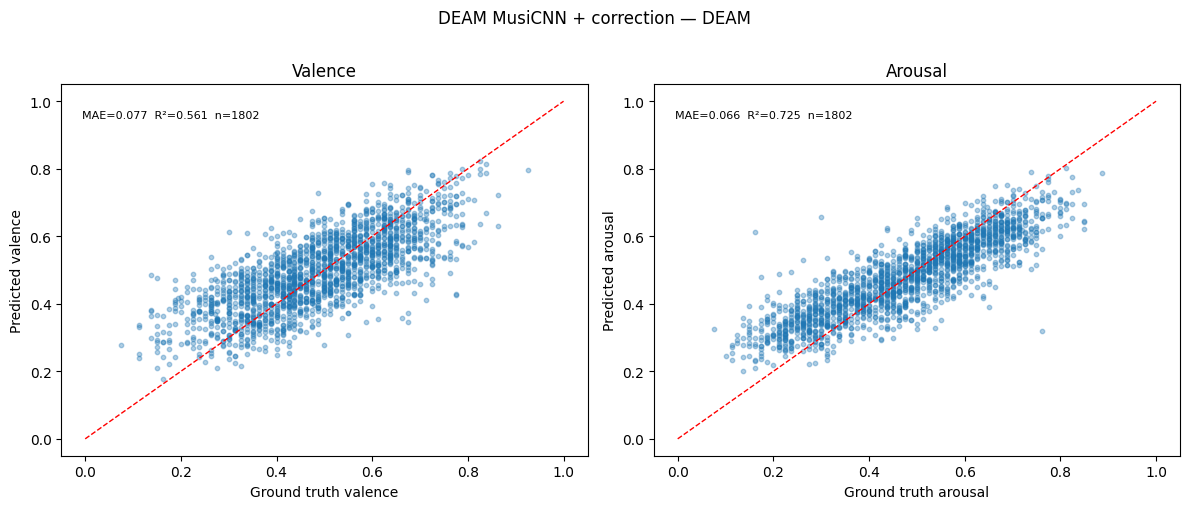

Saved: deam_musicnn_+_correction_—_deam.png

── PMEmo ──
  PMEmo:
        Dim   n    MAE     R² Pearson r Kendall τ
    valence 767 0.0945 0.4538    0.6855    0.4999
    arousal 767 0.1150 0.4240    0.7240    0.5307


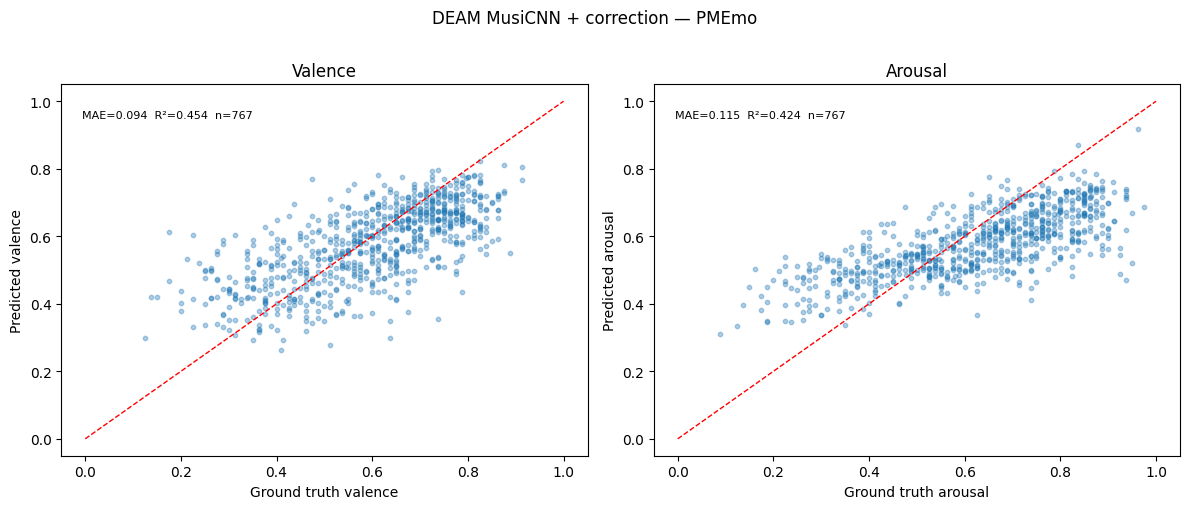

Saved: deam_musicnn_+_correction_—_pmemo.png

── MERGE ──
  MERGE:
        Dim    n    MAE     R² Pearson r Kendall τ
    valence 3232 0.1932 0.0092    0.2863    0.1999
    arousal 3232 0.0937 0.2244    0.6338    0.4589


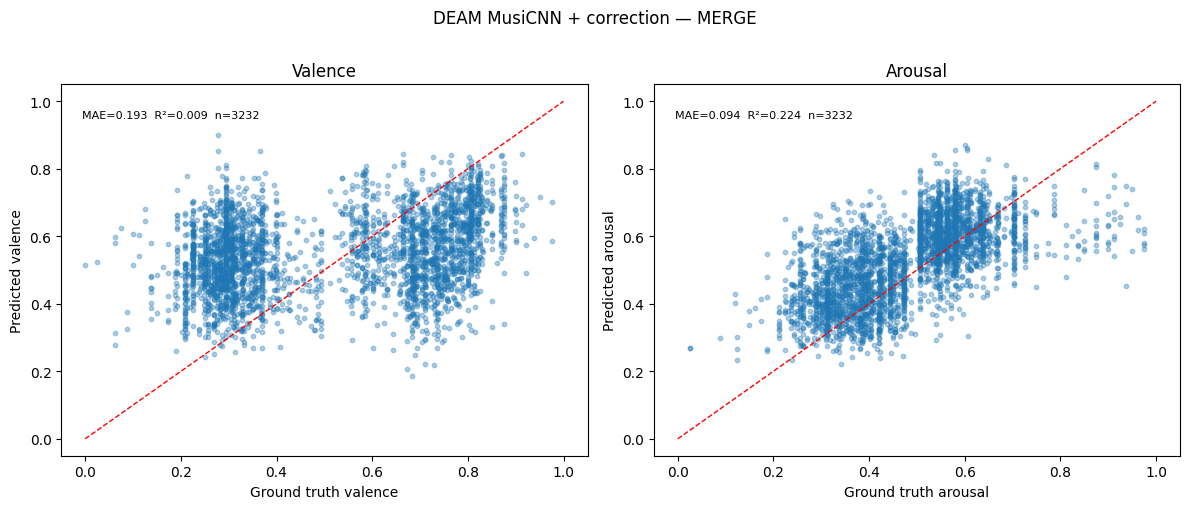

Saved: deam_musicnn_+_correction_—_merge.png


In [7]:
for ds_name, df in all_results.items():
    print_metrics(df, ds_name)
    plot_scatter(df, f"DEAM MusiCNN + correction — {ds_name}")

In [8]:
save_results(all_results, MODEL_TAG)

Saved: deam-musicnn-valence-corrected_results.csv  (5801 rows)


## 6. Qualitative Spot-checks

In [9]:
download_spot_checks(SPOTCHECK_DIR)

In [10]:
spot_df = run_spot_checks(predictor.predict, SPOTCHECK_DIR)


Dont Stop Me Now
  Expected:  v=0.90  a=0.95
  Predicted: v=0.65  a=0.58

Clair De Lune
  Expected:  v=0.70  a=0.10
  Predicted: v=0.42  a=0.35

Killing In The Name
  Expected:  v=0.30  a=0.95
  Predicted: v=0.49  a=0.70

Hurt Johnny Cash
  Expected:  v=0.10  a=0.15
  Predicted: v=0.46  a=0.36

Walking On Sunshine
  Expected:  v=0.95  a=0.85
  Predicted: v=0.71  a=0.64

Completed 5 spot-checks.


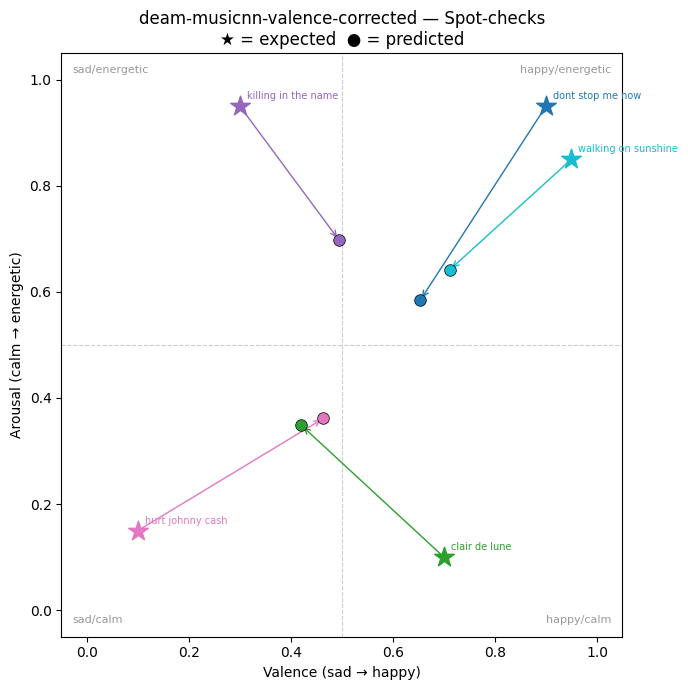

Saved: deam-musicnn-valence-corrected_spotchecks.png


In [11]:
plot_spot_checks(spot_df, MODEL_TAG)

## 7. Runtime & Memory Profiling

In [12]:
test_audio = next(
    (SPOTCHECK_DIR / f"{t['title']}.mp3" for t in SPOT_CHECKS
     if (SPOTCHECK_DIR / f"{t['title']}.mp3").exists()),
    None,
)

if test_audio is None:
    print("No audio for profiling — run Section 6 first.")
else:
    prof = profile_predictor(predictor.predict, test_audio, n=5)
    print(f"DEAM MusiCNN + correction — profiling on {test_audio.name}:")
    print(f"  Mean: {prof['mean_s']:.2f} s/track")
    print(f"  Std:  {prof['std_s']:.3f} s")
    print(f"  Peak RAM: {prof['peak_mb']:.1f} MB")

DEAM MusiCNN + correction — profiling on dont_stop_me_now.mp3:
  Mean: 13.17 s/track
  Std:  0.098 s
  Peak RAM: 0.1 MB


## 8. Summary

In [13]:
prof_or_none = prof if "prof" in dir() else None
print_summary(all_results, spot_df, prof_or_none, MODEL_TAG)

DEAM-MUSICNN-VALENCE-CORRECTED — BENCHMARK SUMMARY

── Dataset metrics ──

── all datasets ──
  DEAM:
        Dim    n    MAE     R² Pearson r Kendall τ
    valence 1802 0.0774 0.5606    0.7505    0.5579
    arousal 1802 0.0662 0.7253    0.8650    0.6903
  MERGE:
        Dim    n    MAE     R² Pearson r Kendall τ
    valence 3232 0.1932 0.0092    0.2863    0.1999
    arousal 3232 0.0937 0.2244    0.6338    0.4589
  PMEmo:
        Dim   n    MAE     R² Pearson r Kendall τ
    valence 767 0.0945 0.4538    0.6855    0.4999
    arousal 767 0.1150 0.4240    0.7240    0.5307

── Spot-checks ──
              title  exp_valence  exp_arousal  valence  arousal
   dont stop me now         0.90         0.95     0.65     0.58
      clair de lune         0.70         0.10     0.42     0.35
killing in the name         0.30         0.95     0.49     0.70
   hurt johnny cash         0.10         0.15     0.46     0.36
walking on sunshine         0.95         0.85     0.71     0.64

── Runtime ──
  13.1